# Конкурское задание

## Импорт нужных библиотек

In [103]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sb
import os

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn import tree

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

## Чтение датасета и экспорт его в базу данных

In [71]:
data = pd.read_csv("GameDataSet.csv", index=False) # Записываем DataSet как объект DataFrame в переменную data

In [73]:
data # Смотрим таблицу

,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid
0,86273129,500000000,4,2.1,6.9,0.0,0,63546766,4949507,3158756,2122183,12495915,0
1,37276732,500000000,4,1.8,3.6,0.0,0,28339753,2164478,1253185,809821,4709492,0
2,26663595,100000000,4,1.5,3.2,0.0,0,18777988,1812094,1050600,713912,4308998,0
3,17971552,100000000,4,1.4,4.4,0.0,0,13018610,1552950,774012,406184,2219794,0
4,14464235,500000000,4,0.8,1.5,0.0,0,9827328,2124154,1047741,380670,1084340,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1725,112408,1000000,4,0.9,1.8,0.0,16,101036,3607,3237,1229,3297,0
1726,111595,1000000,4,0.9,2.3,0.0,16,88950,14856,4297,1385,2103,0
1727,110723,10000000,4,0.9,1.9,0.0,16,64184,18332,9385,6688,12132,0
1728,109530,5000000,4,1.9,4.1,0.0,16,99987,4766,1469,953,2353,0


In [106]:
data.isna().sum()

total ratings       0
average rating      0
growth (30 days)    0
category            0
5 star ratings      0
3 star ratings      0
2 star ratings      0
cluster             0
dtype: int64

## Задание 1.1. Создаем базу данных и записываем в нее DataSet

In [7]:
con = sqlite3.connect("GameDataSet2.db") # Создаем файл базы данных
data.to_sql("user", con=con, if_exists="append", index=False) # Записываем в уже созданный файл DataSet

1730

## Задание 1.2. С помощью модели разделяем данные на кластеры и записываем их в таблицу

### Я выбрал модель KMeans, т.к в ней удобно можно самому задать количество кластеров

In [8]:
kmeans = KMeans(n_clusters=3) # Создаем объект модели KMeans, который расспределит данные по кластерам

In [10]:
pca = PCA(n_components=2) # Создаем объект PCA, который позволит снизить размерность данных до 2-хмерной
data_2d = pca.fit_transform(data) # Снижаем размерность DataSet и записываем в переменную data_2d

In [11]:
kmeans.fit(data_2d) # Обучаем модель KMeans на данных из переменной data_2d

C:\Users\demoexam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


KMeans(n_clusters=3)

In [13]:
labels = kmeans.fit_predict(data) # Проводим данные DataSet'а, записанного в переменную data через модель KMeans
# и записываем результат в переменную, получая кластеры

C:\Users\demoexam\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


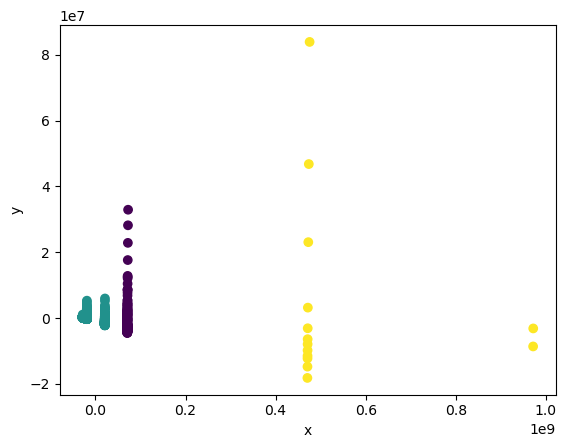

In [15]:
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap='viridis') # Создаем график для визуализации результата работы модели
plt.xlabel('x') # Называем ось x
plt.ylabel('y') # Называем ось y
plt.show() # Выводим график с кластерами на экран

### Добавление кластеров в таблицу

In [77]:
labels = pd.Series(labels) # Меняем тип данных с array на Series, для более удобного совмещения данных с DataSet

In [78]:
labels # Смотрим результат преобразования

0       2
1       2
2       0
3       0
4       2
       ..
1725    1
1726    1
1727    1
1728    1
1729    1
Name: cluster, Length: 1730, dtype: int32

In [79]:
labels.name = "cluster" # Добавляем имя Series, чтобы потом это имя перенеслось в таблицу
data = pd.concat([data, labels], axis=1) # Соединяем Series в кластерами и таблицу

In [80]:
data # Смотрим результат

,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid,cluster
0,86273129.0,500000000.0,4.0,2.1,6.9,0.0,0.0,63546766.0,4949507.0,3158756.0,2122183.0,12495915.0,0.0,2
1,37276732.0,500000000.0,4.0,1.8,3.6,0.0,0.0,28339753.0,2164478.0,1253185.0,809821.0,4709492.0,0.0,2
2,26663595.0,100000000.0,4.0,1.5,3.2,0.0,0.0,18777988.0,1812094.0,1050600.0,713912.0,4308998.0,0.0,0
3,17971552.0,100000000.0,4.0,1.4,4.4,0.0,0.0,13018610.0,1552950.0,774012.0,406184.0,2219794.0,0.0,0
4,14464235.0,500000000.0,4.0,0.8,1.5,0.0,0.0,9827328.0,2124154.0,1047741.0,380670.0,1084340.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1726,111595.0,1000000.0,4.0,0.9,2.3,0.0,16.0,88950.0,14856.0,4297.0,1385.0,2103.0,0.0,1
1727,110723.0,10000000.0,4.0,0.9,1.9,0.0,16.0,64184.0,18332.0,9385.0,6688.0,12132.0,0.0,1
1728,109530.0,5000000.0,4.0,1.9,4.1,0.0,16.0,99987.0,4766.0,1469.0,953.0,2353.0,0.0,1
1729,108917.0,10000000.0,3.0,1.1,2.5,0.0,16.0,50813.0,16480.0,11825.0,6166.0,23631.0,0.0,1


## Задание 1.3. Делаем таблицу в редакторе таблиц и смотрим ее. Так же смотрим на сколько в DataSet отклоняются значения

### Проверка уже готовой информационной таблицы

In [88]:
inf_table = pd.read_csv("inf_table.csv", index=False) # Открываем, заранее сделанную таблицу, и записываем в переменную inf_table

In [92]:
inf_table # Смотрим таблицу

,Название,Перевод,Описание,Тип данных,Система измерения
0,total ratings,Итоговый рейтинг,Количество оценок за все время,Целочисленный,-
1,installs,Установки,Количество установок за все время,Целочисленный,-
2,average rating,Средний рейтинг,Средний рейтинг из всех оценок,Целочисленный,-
3,growth (30 days),Рост (30 дней),Рост рейтинга за последние 30 дней,Число с плавующей точкой,-
4,growth (60 days),Рост (60 дней),Рост рейтинга за последние 60 дней,Число с плавующей точкой,-
5,price,Цена,Цена игры,Число с плавующей точкой,Доллары
6,category,Категория,Категория игры (в данном случае получала ли он...,Целочисленный,-
7,5 star ratings,Рейтинг 5 звезд,Количество 5-тизвездочных оценок,Целочисленный,-
8,4 star ratings,Рейтинг 4 звезды,Количество 4-тизвездочных оценок,Целочисленный,-
9,3 star ratings,Рейтинг 3 звезды,Количество 3-тизвездочных оценок,Целочисленный,-


### Проверка на отклонение от нормы значений и визуализация значений

In [102]:
data

,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid
0,86273129,500000000,4,2.1,6.9,0.0,0,63546766,4949507,3158756,2122183,12495915,0
1,37276732,500000000,4,1.8,3.6,0.0,0,28339753,2164478,1253185,809821,4709492,0
2,26663595,100000000,4,1.5,3.2,0.0,0,18777988,1812094,1050600,713912,4308998,0
3,17971552,100000000,4,1.4,4.4,0.0,0,13018610,1552950,774012,406184,2219794,0
4,14464235,500000000,4,0.8,1.5,0.0,0,9827328,2124154,1047741,380670,1084340,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1725,112408,1000000,4,0.9,1.8,0.0,16,101036,3607,3237,1229,3297,0
1726,111595,1000000,4,0.9,2.3,0.0,16,88950,14856,4297,1385,2103,0
1727,110723,10000000,4,0.9,1.9,0.0,16,64184,18332,9385,6688,12132,0
1728,109530,5000000,4,1.9,4.1,0.0,16,99987,4766,1469,953,2353,0


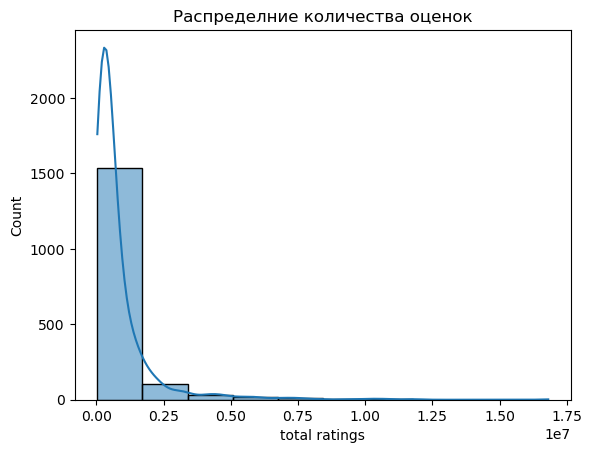

In [140]:
sb.histplot(data['total ratings'], bins=10, kde=True)
plt.title('Распределние количества оценок')
plt.show()

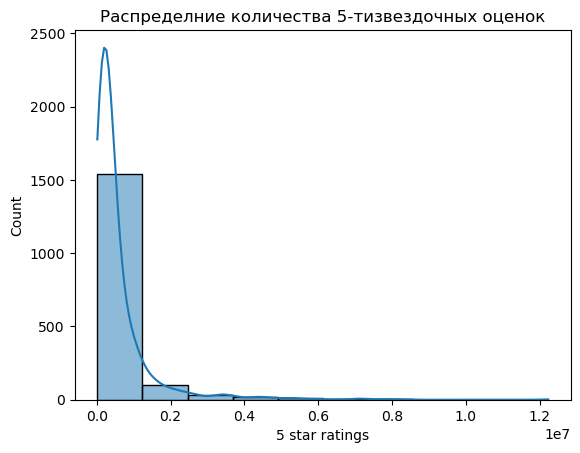

In [159]:
sb.histplot(data['5 star ratings'], bins=10, kde=True)
plt.title('Распределние количества 5-тизвездочных оценок')
plt.show()

In [148]:
data

,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid
6,11936964,100000000,3,1.8,5.6,0.0,0,5954262,1041297,853099,719378,3368926,0
7,9633929,500000000,4,0.3,0.8,0.0,0,6579369,991341,614643,349003,1099571,0
8,7578630,100000000,4,1.0,2.5,0.0,0,5382545,500696,351523,238986,1104879,0
9,6268377,100000000,4,0.4,1.0,0.0,0,4509647,605510,319332,167792,666094,0
10,5681934,100000000,4,0.2,0.5,0.0,0,3866308,527159,326294,186593,775578,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1725,112408,1000000,4,0.9,1.8,0.0,16,101036,3607,3237,1229,3297,0
1726,111595,1000000,4,0.9,2.3,0.0,16,88950,14856,4297,1385,2103,0
1727,110723,10000000,4,0.9,1.9,0.0,16,64184,18332,9385,6688,12132,0
1728,109530,5000000,4,1.9,4.1,0.0,16,99987,4766,1469,953,2353,0


In [156]:
data["average rating"].value_counts()

average rating
4    1556
3     157
2       1
Name: count, dtype: int64

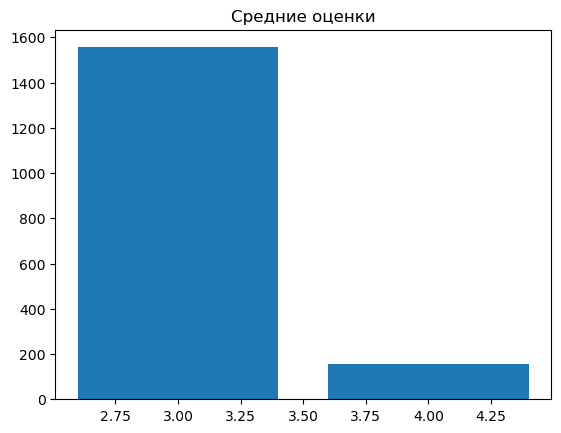

In [171]:
plt.bar(data["average rating"].unique(), data["average rating"].value_counts())
plt.title('Средние оценки')
plt.show()

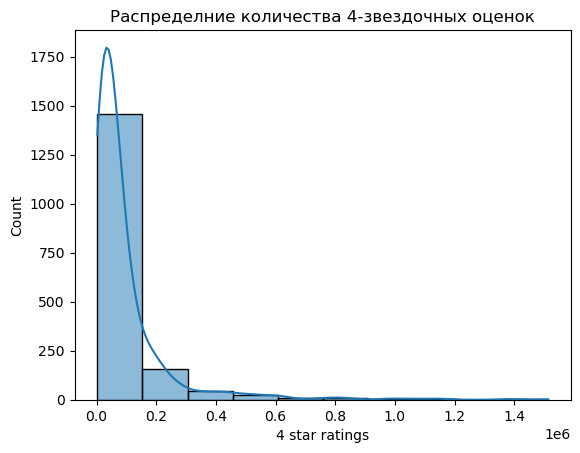

In [158]:
sb.histplot(data['4 star ratings'], bins=10, kde=True)
plt.title('Распределние количества 4-звездочных оценок')
plt.show()

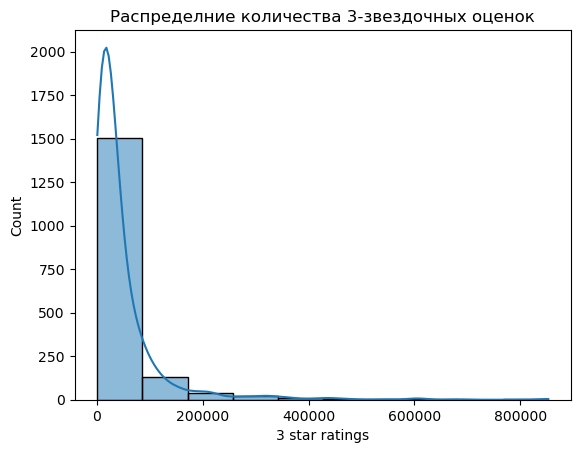

In [160]:
sb.histplot(data['3 star ratings'], bins=10, kde=True)
plt.title('Распределние количества 3-звездочных оценок')
plt.show()

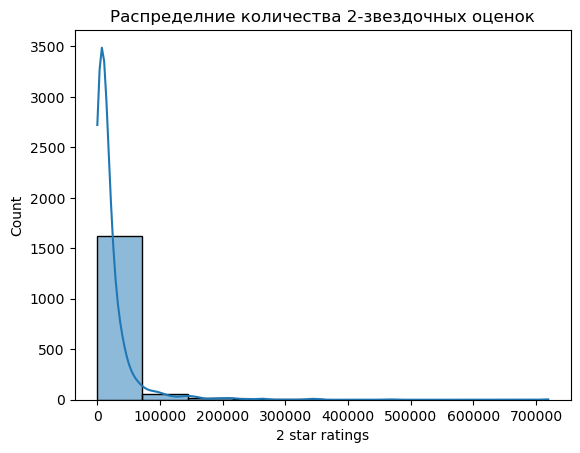

In [161]:
sb.histplot(data['2 star ratings'], bins=10, kde=True)
plt.title('Распределние количества 2-звездочных оценок')
plt.show()

#### Все данные имеют отклонение вправо

### По ходу выполнение задания, было выянено, что значенеи "2" в таблице "average rating" появляется всего один раз и ни как не влияет на обучение модели в будущем. Было принято решение удалить эту стрчоку из-за ее ненадобности

In [ ]:
data.loc[data['average rating'] == 2] # Находим строчку, в которой значение "average rating" равно "2"

In [82]:
data = data.drop([1425], axis=0) # Удаляем строчку по ее id

In [83]:
data["average rating"].unique() # Проверяем, что значений с "2" точно не осталось

array([4., 3.])

## Задание 1.4. Смотрим данные по заданию

### Общее количество 5-тизвездочных рейтингов по кластерам

In [84]:
data

,total ratings,installs,average rating,growth (30 days),growth (60 days),price,category,5 star ratings,4 star ratings,3 star ratings,2 star ratings,1 star ratings,paid,cluster
0,86273129.0,500000000.0,4.0,2.1,6.9,0.0,0.0,63546766.0,4949507.0,3158756.0,2122183.0,12495915.0,0.0,2
1,37276732.0,500000000.0,4.0,1.8,3.6,0.0,0.0,28339753.0,2164478.0,1253185.0,809821.0,4709492.0,0.0,2
2,26663595.0,100000000.0,4.0,1.5,3.2,0.0,0.0,18777988.0,1812094.0,1050600.0,713912.0,4308998.0,0.0,0
3,17971552.0,100000000.0,4.0,1.4,4.4,0.0,0.0,13018610.0,1552950.0,774012.0,406184.0,2219794.0,0.0,0
4,14464235.0,500000000.0,4.0,0.8,1.5,0.0,0.0,9827328.0,2124154.0,1047741.0,380670.0,1084340.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1725,112408.0,1000000.0,4.0,0.9,1.8,0.0,16.0,101036.0,3607.0,3237.0,1229.0,3297.0,0.0,1
1726,111595.0,1000000.0,4.0,0.9,2.3,0.0,16.0,88950.0,14856.0,4297.0,1385.0,2103.0,0.0,1
1727,110723.0,10000000.0,4.0,0.9,1.9,0.0,16.0,64184.0,18332.0,9385.0,6688.0,12132.0,0.0,1
1728,109530.0,5000000.0,4.0,1.9,4.1,0.0,16.0,99987.0,4766.0,1469.0,953.0,2353.0,0.0,1


In [44]:
data.groupby("cluster")["5 star ratings"].sum()

cluster
0    455810482
1    598753840
2    264096124
Name: 5 star ratings, dtype: int64

### В процентах показать отношение 4 звездочных рейтинга для каждого id по среднему всех 4 звездочных рейтингов

In [45]:
mean_four_star = data["4 star ratings"].mean()

In [49]:
data["4 star ratings"] / (mean_four_star/100)

0       4250.817858
1       1858.932968
2       1556.292684
3       1333.730328
4       1824.301240
           ...     
1725       3.097824
1726      12.758877
1727      15.744193
1728       4.093215
1729      14.153627
Name: 4 star ratings, Length: 1730, dtype: float64

### Количество экземпляров по кластерам

In [57]:
data.groupby("cluster")["5 star ratings"].count()

cluster
0     204
1    1512
2      14
Name: 5 star ratings, dtype: int64

### Для каждого экземпляра категории каждого кластера посчитать среднее значения 3 звездочного рейтинга

In [61]:
data.groupby(["cluster", "category"])["3 star ratings"].mean()

cluster  category
0        0           2.123066e+05
         1           3.637858e+05
         2           1.261052e+05
         3           7.138820e+04
         4           3.993600e+04
         6           2.453807e+05
         7           3.281275e+04
         8           8.100440e+04
         9           9.271376e+04
         10          1.269034e+05
         11          1.075352e+05
         12          1.340457e+05
         13          2.077376e+05
         14          4.671135e+05
         15          2.854335e+05
         16          8.276600e+04
1        0           8.560603e+04
         1           2.990035e+04
         2           5.104828e+04
         3           1.555282e+04
         4           1.607989e+04
         5           1.824486e+04
         6           4.881192e+04
         7           7.327333e+03
         8           9.276263e+03
         9           4.772441e+04
         10          3.628128e+04
         11          3.673757e+04
         12          4.680380e

## Задание 1.5. Выбираем нужные нам данные и удаляем не нужные

### Обучаем простую модель, для определния того, какие данные она использует

In [90]:
y = data["average rating"] # Выделяем интересующую цель, которую модель будет предсказывать
x = data[data.columns[data.columns != "average rating"]] # В входные данные для модели пойдут все, помимо предсказываемой
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # С помощью метода train_test_split
# делим данные на выборки: тестовую (20 процентов от всех данных) и тренировочную (80 процентов от всех данных)

clf = tree.DecisionTreeClassifier() # Создаем объект модели DecisionTreeClassifier

In [91]:
clf.fit(X_train, y_train) # Тренируем модель на тренировочных данных

DecisionTreeClassifier()

In [92]:
clf.feature_importances_ # Получаем массив, по которому можно понять, какие данные использовала модель

array([0.04176729, 0.00554586, 0.03243587, 0.02026508, 0.        ,
       0.01537206, 0.43527054, 0.05000866, 0.00756254, 0.01833455,
       0.37343754, 0.        , 0.        ])

### Для удобства визуализируем данные и смотрим, какие нужно оставить, а какие нужно убрать

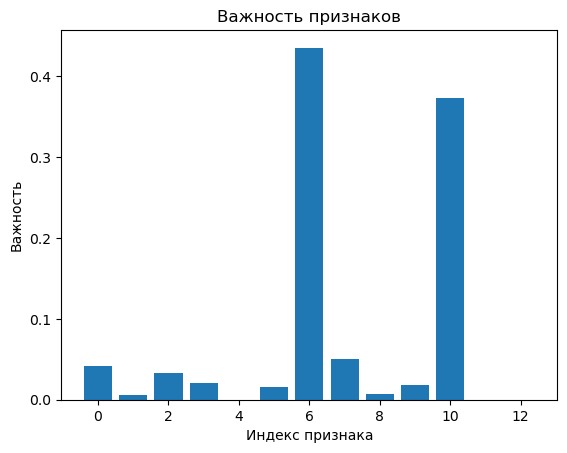

In [93]:
plt.bar(range(len(clf.feature_importances_)), clf.feature_importances_)
plt.xlabel('Индекс признака')
plt.ylabel('Важность')
plt.title('Важность признаков')
plt.show()

#### Для еще большего удобства, было принято решение вывести название признаков, через индексы

In [100]:
for idx, importance in enumerate(clf.feature_importances_):
    print(f'Индекс: {idx}, Признак: {data.columns[idx]}, Важность: {importance}')

Индекс: 0, Признак: total ratings, Важность: 0.04176729323308271
Индекс: 1, Признак: installs, Важность: 0.005545864661654135
Индекс: 2, Признак: average rating, Важность: 0.032435871586760576
Индекс: 3, Признак: growth (30 days), Важность: 0.020265076818854675
Индекс: 4, Признак: growth (60 days), Важность: 0.0
Индекс: 5, Признак: price, Важность: 0.015372060372060386
Индекс: 6, Признак: category, Важность: 0.43527054187657943
Индекс: 7, Признак: 5 star ratings, Важность: 0.05000865611543041
Индекс: 8, Признак: 4 star ratings, Важность: 0.007562542720437458
Индекс: 9, Признак: 3 star ratings, Важность: 0.018334554020046724
Индекс: 10, Признак: 2 star ratings, Важность: 0.37343753859509354
Индекс: 11, Признак: 1 star ratings, Важность: 0.0
Индекс: 12, Признак: paid, Важность: 0.0


#### Для сравнения создаем матрицу корреляции

In [98]:
cor_matrix = data.corr()

<Axes: >

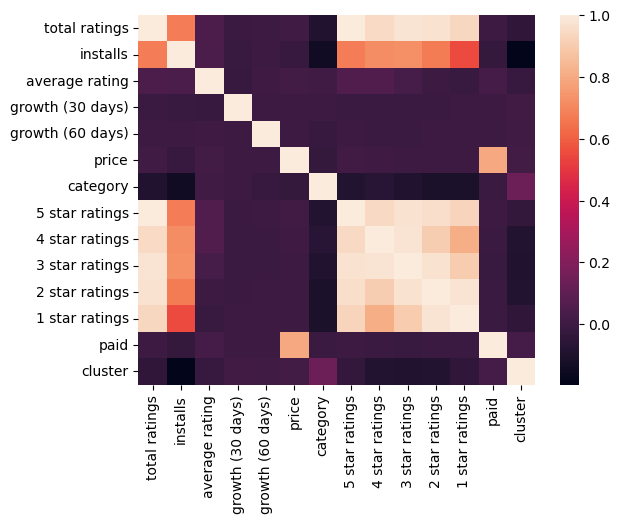

In [99]:
sb.heatmap(cor_matrix)

#### Все признаки, которые меньше всего влияют на тот, который мы будем предсказывать, а именно "average rating", удаляем. Признак "cluster" был оставлен, так как эти данные будут нужны еще в будущем

In [101]:
data = data.drop(["paid", "1 star ratings", "4 star ratings", "price", "growth (60 days)", "installs"], axis=1)

In [102]:
data

,total ratings,average rating,growth (30 days),category,5 star ratings,3 star ratings,2 star ratings,cluster
0,86273129.0,4.0,2.1,0.0,63546766.0,3158756.0,2122183.0,2
1,37276732.0,4.0,1.8,0.0,28339753.0,1253185.0,809821.0,2
2,26663595.0,4.0,1.5,0.0,18777988.0,1050600.0,713912.0,0
3,17971552.0,4.0,1.4,0.0,13018610.0,774012.0,406184.0,0
4,14464235.0,4.0,0.8,0.0,9827328.0,1047741.0,380670.0,2
...,...,...,...,...,...,...,...,...
1725,112408.0,4.0,0.9,16.0,101036.0,3237.0,1229.0,1
1726,111595.0,4.0,0.9,16.0,88950.0,4297.0,1385.0,1
1727,110723.0,4.0,0.9,16.0,64184.0,9385.0,6688.0,1
1728,109530.0,4.0,1.9,16.0,99987.0,1469.0,953.0,1


In [105]:
data.to_sql("adv_user", con=con, if_exists="append", index=False) # Записываем в уже созданный файл DataSet

1729